In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import simpy

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

LAMBDA = 8.0
MU = 10.0
M_QUEUE = 5
LOSS_THRESHOLD = 0.05

LAMBDA, MU, M_QUEUE, LOSS_THRESHOLD

(8.0, 10.0, 5, 0.05)

In [ ]:
def mm1_finite_metrics(lambda_rate: float, mu: float, m_queue: int) -> dict:
    K = m_queue + 1
    rho = lambda_rate / mu
    ns = np.arange(0, K + 1, dtype=float)

    if rho == 1.0:
        p = np.ones(K + 1) / (K + 1)
    else:
        p = (rho ** ns)
        p /= p.sum()

    P_loss = float(p[K])
    L = float(np.sum(ns * p))

    Lq = float(np.sum(np.maximum(0.0, ns - 1.0) * p))

    lambda_eff = lambda_rate * (1.0 - P_loss)
    if lambda_eff <= 0:
        W = Wq = np.nan
    else:

        W = L / lambda_eff
        Wq = Lq / lambda_eff

    rho_util = lambda_eff / mu

    return {
        "lambda": lambda_rate,
        "mu": mu,
        "m_queue": m_queue,
        "K": K,
        "rho": rho,
        "P_loss": P_loss,
        "lambda_eff": lambda_eff,
        "L": L,
        "Lq": Lq,
        "Wq": Wq,
        "W": W,
        "rho_util": rho_util,
        "p_dist": p,
    }

base = mm1_finite_metrics(LAMBDA, MU, M_QUEUE)
pd.Series({k: base[k] for k in base if k != "p_dist"})

lambda         8.000000
mu            10.000000
m_queue        5.000000
K              6.000000
rho            0.800000
P_loss         0.066342
lambda_eff     7.469267
L              2.142434
Lq             1.395507
Wq             0.186833
W              0.286833
rho_util       0.746927
dtype: float64

In [ ]:

K = base["K"]
pd.DataFrame({"n в системе": np.arange(0, K + 1), "P_n": base["p_dist"]})

,n в системе,P_n
0,0,0.253073
1,1,0.202459
2,2,0.161967
3,3,0.129574
4,4,0.103659
5,5,0.082927
6,6,0.066342


In [ ]:
def find_min_m_for_loss(lambda_rate: float, mu: float, threshold: float, m_max: int = 200) -> tuple[int | None, pd.DataFrame]:
    rows = []
    chosen = None
    for m in range(0, m_max + 1):
        met = mm1_finite_metrics(lambda_rate, mu, m)
        rows.append(
            {
                "m": m,
                "P_loss": met["P_loss"],
                "Wq": met["Wq"],
                "Lq": met["Lq"],
                "rho_util": met["rho_util"],
            }
        )
        if chosen is None and met["P_loss"] <= threshold:
            chosen = m
    return chosen, pd.DataFrame(rows)


m_opt_theory, df_m_sweep = find_min_m_for_loss(LAMBDA, MU, LOSS_THRESHOLD)
print("Минимальное m (теория), при котором P_loss <= 5%:", m_opt_theory)

df_m_sweep.head(12)

Минимальное m (теория), при котором P_loss <= 5%: 7


,m,P_loss,Wq,Lq,rho_util
0,0,0.444444,0.000000,0.000000,0.444444
1,1,0.262295,0.044444,0.262295,0.590164
2,2,0.173442,0.085246,0.563686,0.661247
3,3,0.121847,0.122493,0.860543,0.702523
4,4,0.088819,0.156307,1.139388,0.728944
5,5,0.066342,0.186833,1.395507,0.746927
6,6,0.050399,0.214243,1.627567,0.759681
7,7,0.038756,0.238725,1.835782,0.768995
8,8,0.030073,0.260478,2.021156,0.775942
9,9,0.023493,0.279710,2.185109,0.781206


In [ ]:
M_PLOT_MAX = 25
m_plot = np.arange(0, M_PLOT_MAX + 1)
theory_rows = [mm1_finite_metrics(LAMBDA, MU, int(m)) for m in m_plot]
df_theory_curve = pd.DataFrame(
    {
        "m": m_plot,
        "P_loss": [r["P_loss"] for r in theory_rows],
        "Wq": [r["Wq"] for r in theory_rows],
        "Lq": [r["Lq"] for r in theory_rows],
    }
)
df_theory_curve.tail()

,m,P_loss,Wq,Lq
21,21,0.001485,0.383646,3.064613
22,22,0.001186,0.386343,3.087074
23,23,0.000948,0.388613,3.105953
24,24,0.000758,0.390519,3.121788
25,25,0.000606,0.392118,3.135045


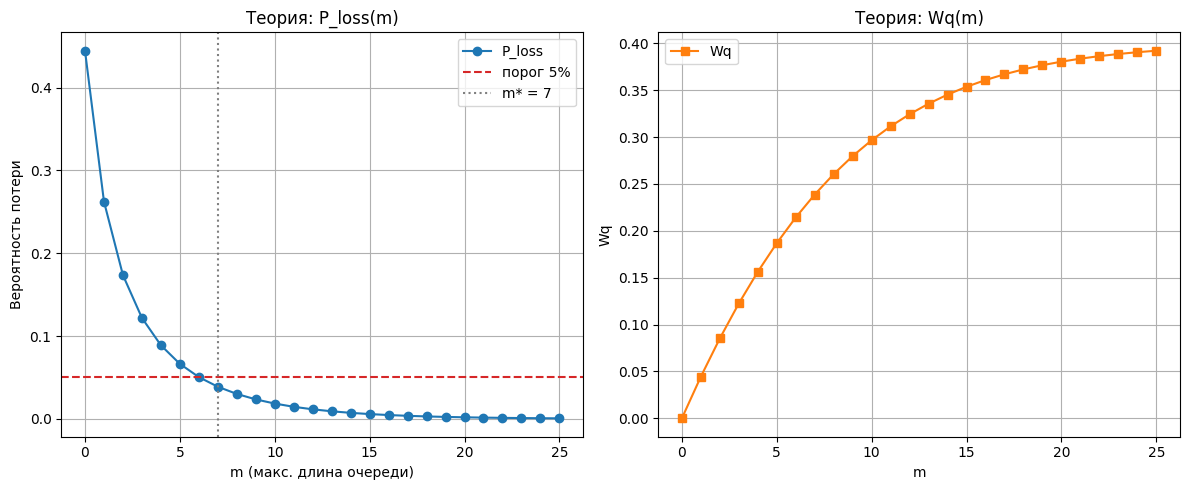

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))


ax[0].plot(df_theory_curve["m"], df_theory_curve["P_loss"], "o-", label="P_loss")
ax[0].axhline(LOSS_THRESHOLD, color="C3", linestyle="--", label=f"порог {LOSS_THRESHOLD:.0%}")
if m_opt_theory is not None:
    ax[0].axvline(m_opt_theory, color="gray", linestyle=":", label=f"m* = {m_opt_theory}")
ax[0].set_xlabel("m (макс. длина очереди)")
ax[0].set_ylabel("Вероятность потери")
ax[0].set_title("Теория: P_loss(m)")
ax[0].legend()


ax[1].plot(df_theory_curve["m"], df_theory_curve["Wq"], "s-", color="C1", label="Wq")
ax[1].set_xlabel("m")
ax[1].set_ylabel("Wq")
ax[1].set_title("Теория: Wq(m)")
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
def simulate_mm1_finite(
    lambda_rate: float,
    mu: float,
    m_queue: int,
    sim_time: float = 80_000.0,
    warmup: float = 8_000.0,
    seed: int = 42,
) -> dict:
    K = m_queue + 1
    env = simpy.Environment()
    server = simpy.Resource(env, capacity=1)
    rng = np.random.default_rng(seed)

    in_system = 0

    stats = {
        "area_sys": 0.0,
        "area_q": 0.0,
        "area_busy": 0.0,
        "last_t": 0.0,
        "arrived": 0,
        "lost": 0,
        "served": 0,
        "sum_wq": 0.0,
        "sum_w": 0.0,
    }

    def accumulate():
        t0 = max(stats["last_t"], warmup)
        t1 = env.now
        if t1 > t0:
            dt = t1 - t0
            stats["area_sys"] += in_system * dt
            stats["area_q"] += max(0, in_system - 1) * dt
            stats["area_busy"] += (1.0 if in_system > 0 else 0.0) * dt
        stats["last_t"] = env.now

    def customer():
        nonlocal in_system
        arrival = env.now
        accumulate()

        with server.request() as req:
            yield req
            accumulate()

            wait = env.now - arrival
            yield env.timeout(rng.exponential(1.0 / mu))
            accumulate()

        accumulate()
        in_system -= 1

        if arrival >= warmup:
            stats["served"] += 1
            stats["sum_wq"] += wait
            stats["sum_w"] += env.now - arrival

    def arrivals():
        nonlocal in_system
        while True:
            yield env.timeout(rng.exponential(1.0 / lambda_rate))

            accumulate()
            stats["arrived"] += 1
            if in_system < K:
                in_system += 1
                env.process(customer())
            else:
                stats["lost"] += 1

    env.process(arrivals())
    env.run(until=sim_time)
    accumulate()

    horizon = sim_time - warmup
    arr = stats["arrived"]

    P_loss_emp = stats["lost"] / arr if arr > 0 else np.nan
    L_emp = stats["area_sys"] / horizon
    Lq_emp = stats["area_q"] / horizon
    rho_util_emp = stats["area_busy"] / horizon
    served = stats["served"]
    Wq_emp = stats["sum_wq"] / served if served > 0 else np.nan
    W_emp = stats["sum_w"] / served if served > 0 else np.nan

    return {
        "P_loss": float(P_loss_emp),
        "L": float(L_emp),
        "Lq": float(Lq_emp),
        "Wq": float(Wq_emp),
        "W": float(W_emp),
        "rho_util": float(rho_util_emp),
        "arrived": arr,
        "lost": stats["lost"],
        "served": served,
        "sim_time": sim_time,
        "warmup": warmup,
        "seed": seed,
    }

sim = simulate_mm1_finite(LAMBDA, MU, M_QUEUE, sim_time=80_000, warmup=8_000, seed=42)
th = mm1_finite_metrics(LAMBDA, MU, M_QUEUE)

compare = pd.DataFrame(
    {
        "metric": ["P_loss", "L", "Lq", "Wq", "W", "rho_util"],
        "theory": [th["P_loss"], th["L"], th["Lq"], th["Wq"], th["W"], th["rho_util"]],
        "simulation": [sim["P_loss"], sim["L"], sim["Lq"], sim["Wq"], sim["W"], sim["rho_util"]],
    }
)
compare["abs_err"] = (compare["simulation"] - compare["theory"]).abs()
compare["rel_err_%"] = np.where(
    compare["theory"] != 0, compare["abs_err"] / compare["theory"].abs() * 100.0, np.nan
)
print("Прибыло заявок:", sim["arrived"], " потерь:", sim["lost"], " обслужено после warmup:", sim["served"])
compare

Прибыло заявок: 640303  потерь: 42470  обслужено после warmup: 538224


,metric,theory,simulation,abs_err,rel_err_%
0,P_loss,0.066342,0.066328,0.000014,0.020621
1,L,2.142434,2.141055,0.001379,0.064373
2,Lq,1.395507,1.394933,0.000574,0.041146
3,Wq,0.186833,0.186603,0.000230,0.123128
4,W,0.286833,0.286414,0.000419,0.146138
5,rho_util,0.746927,0.746122,0.000805,0.107768


In [ ]:
sim_time_sweep = 40_000.0
warmup_sweep = 4_000.0

m_values = np.arange(0, 16)
rows = []
for i, mm in enumerate(m_values):
    s = simulate_mm1_finite(LAMBDA, MU, int(mm), sim_time=sim_time_sweep, warmup=warmup_sweep, seed=300 + i)
    t = mm1_finite_metrics(LAMBDA, MU, int(mm))
    rows.append(
        {
            "m": int(mm),
            "P_loss_sim": s["P_loss"],
            "P_loss_theory": t["P_loss"],
            "Wq_sim": s["Wq"],
            "Wq_theory": t["Wq"],
        }
    )

df_cmp = pd.DataFrame(rows)
df_cmp.head()

,m,P_loss_sim,P_loss_theory,Wq_sim,Wq_theory
0,0,0.444555,0.444444,0.000000,0.000000
1,1,0.259417,0.262295,0.044077,0.044444
2,2,0.173531,0.173442,0.085136,0.085246
3,3,0.122781,0.121847,0.122807,0.122493
4,4,0.088886,0.088819,0.156981,0.156307


In [ ]:
m_opt_sim = None
for _, row in df_cmp.iterrows():
    if row["P_loss_sim"] <= LOSS_THRESHOLD:
        m_opt_sim = int(row["m"])
        break
print("m* теория:", m_opt_theory, "| m* симуляция:", m_opt_sim)

m* (теория, P_loss <= порога): 7
m* (симуляция, по тем же прогонам): 7


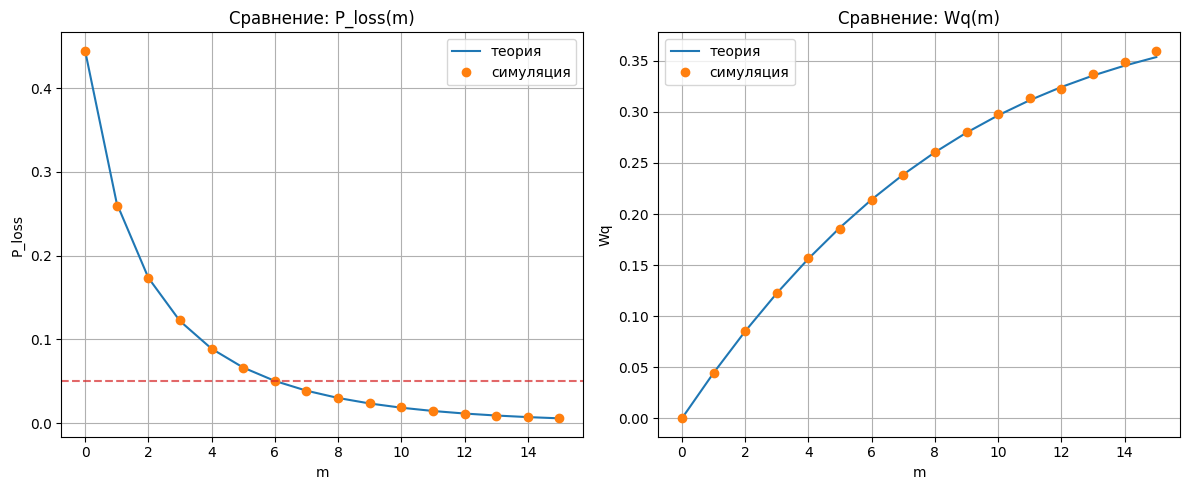

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

mask = df_theory_curve["m"].isin(df_cmp["m"])

ax[0].plot(df_theory_curve.loc[mask, "m"], df_theory_curve.loc[mask, "P_loss"], "-", label="теория")
ax[0].plot(df_cmp["m"], df_cmp["P_loss_sim"], "o", label="симуляция")
ax[0].axhline(LOSS_THRESHOLD, color="C3", linestyle="--", alpha=0.7)
ax[0].set_xlabel("m")
ax[0].set_ylabel("P_loss")
ax[0].set_title("Сравнение: P_loss(m)")
ax[0].legend()

ax[1].plot(df_theory_curve.loc[mask, "m"], df_theory_curve.loc[mask, "Wq"], "-", label="теория")
ax[1].plot(df_cmp["m"], df_cmp["Wq_sim"], "o", label="симуляция")
ax[1].set_xlabel("m")
ax[1].set_ylabel("Wq")
ax[1].set_title("Сравнение: Wq(m)")
ax[1].legend()

plt.tight_layout()
plt.show()